In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np
from random import randint
import torchvision.models as models
import torch.nn as nn
import tqdm
import umap
from sklearn.manifold import TSNE
import seaborn as sns
import os
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
import random
from torch.utils.data import random_split

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
# 1. Paths & Transforms
data_dir = r"C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\data\caltech-101"

transform = transforms.Compose([
    transforms.Resize((224, 224)),    # ResNet input
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 2. Load Caltech-101 via ImageFolder
#    (Caltech-101 has class folders; ImageFolder will infer labels)
full_dataset = ImageFolder(root=data_dir, transform=transform)

# 3. Train/Test Split (e.g., 80/20)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

print(f"Total images: {len(full_dataset)}, Train: {len(train_dataset)}, Test: {len(test_dataset)}")
print("Classes:", full_dataset.classes)

Total images: 9144, Train: 7315, Test: 1829
Classes: ['BACKGROUND_Google', 'Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus', 'buddha', 'butterfly', 'camera', 'cannon', 'car_side', 'ceiling_fan', 'cellphone', 'chair', 'chandelier', 'cougar_body', 'cougar_face', 'crab', 'crayfish', 'crocodile', 'crocodile_head', 'cup', 'dalmatian', 'dollar_bill', 'dolphin', 'dragonfly', 'electric_guitar', 'elephant', 'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'flamingo_head', 'garfield', 'gerenuk', 'gramophone', 'grand_piano', 'hawksbill', 'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline_skate', 'joshua_tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama', 'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome', 'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda', 'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino', 'rooster', 'saxophone', 'schoone

Label: airplanes


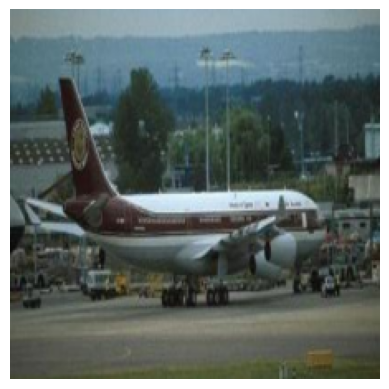

In [3]:
# 4. DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=12)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=12)

# 5. (Optionally) Sanity‐check one batch
def imshow(img):
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

images, labels = next(iter(train_loader))
imshow(images[0])
print("Label:", full_dataset.classes[labels[0]])

In [4]:
# Load pre-trained GoogleNet
googlenet = models.googlenet(pretrained=True)

# Remove final classification layers (fc and aux layers)
model = nn.Sequential(*list(googlenet.children())[:-2])  # Exclude the classifier and auxiliary layers

# Set to evaluation mode
model.eval()

# Send to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# %%
print(model)

c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (4): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (5): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (bra

In [5]:
# Make sure model and dataloader are ready
model.eval()

all_embeddings = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm.tqdm(test_loader):
        images = images.to(device)

        # Pass through model to get features
        features = model(images)  # Output shape: [B, 1024, 1, 1] for GoogleNet
        features = features.squeeze()  # Remove [1,1] dimensions → [B, 1024]

        if len(features.shape) == 1:
            features = features.unsqueeze(0)  # Handle batch size = 1

        all_embeddings.append(features.cpu())
        all_labels.append(labels)

# Stack into arrays
all_embeddings = torch.cat(all_embeddings, dim=0).numpy()  # Shape: [10000, 1024]
all_labels = torch.cat(all_labels, dim=0).numpy()  # Shape: [10000]

100%|██████████| 29/29 [00:21<00:00,  1.37it/s]


In [6]:
os.makedirs(r"C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\embeddings_googlenet", exist_ok=True)
np.save(r"C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\embeddings_googlenet\googlenet_caltech101_embeddings.npy", all_embeddings)
np.save(r"C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\embeddings_googlenet\googlenet_caltech101_labels.npy", all_labels)

In [7]:
print(np.load(r"C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\embeddings_googlenet\googlenet_caltech101_embeddings.npy").shape)
print(np.load(r"C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\embeddings_googlenet\googlenet_caltech101_labels.npy").shape)

(1829, 1024)
(1829,)


In [8]:
embeddings = np.load(r"C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\embeddings_googlenet\googlenet_caltech101_embeddings.npy")
labels = np.load(r"C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\embeddings_googlenet\googlenet_caltech101_labels.npy")

In [9]:
unique_idxs = np.unique(labels)

print("Unique label indices and names:")
for idx in unique_idxs:
    print(f"{idx}: {test_dataset.dataset.classes[idx]}")

Unique label indices and names:
0: BACKGROUND_Google
1: Faces
2: Faces_easy
3: Leopards
4: Motorbikes
5: accordion
6: airplanes
7: anchor
8: ant
9: barrel
10: bass
11: beaver
12: binocular
13: bonsai
14: brain
15: brontosaurus
16: buddha
17: butterfly
18: camera
19: cannon
20: car_side
21: ceiling_fan
22: cellphone
23: chair
24: chandelier
25: cougar_body
26: cougar_face
27: crab
28: crayfish
29: crocodile
30: crocodile_head
31: cup
32: dalmatian
33: dollar_bill
34: dolphin
35: dragonfly
36: electric_guitar
37: elephant
38: emu
39: euphonium
40: ewer
41: ferry
42: flamingo
43: flamingo_head
44: garfield
45: gerenuk
46: gramophone
47: grand_piano
48: hawksbill
49: headphone
50: hedgehog
51: helicopter
52: ibis
53: inline_skate
54: joshua_tree
55: kangaroo
56: ketch
57: lamp
58: laptop
59: llama
60: lobster
61: lotus
62: mandolin
63: mayfly
64: menorah
65: metronome
66: minaret
67: nautilus
68: octopus
69: okapi
70: pagoda
71: panda
72: pigeon
73: pizza
74: platypus
75: pyramid
76: revol

In [10]:
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.5,
    metric='cosine'
)
embedding_2d = reducer.fit_transform(embeddings)  # Shape: [10000, 2]

In [11]:
import matplotlib.cm as cm

cmap = cm.get_cmap("tab20b", 102)  # or "gist_ncar", "nipy_spectral", etc.
palette = [cmap(i) for i in range(102)]

C:\Users\rafin\AppData\Local\Temp\ipykernel_10000\2317267014.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20b", 102)  # or "gist_ncar", "nipy_spectral", etc.


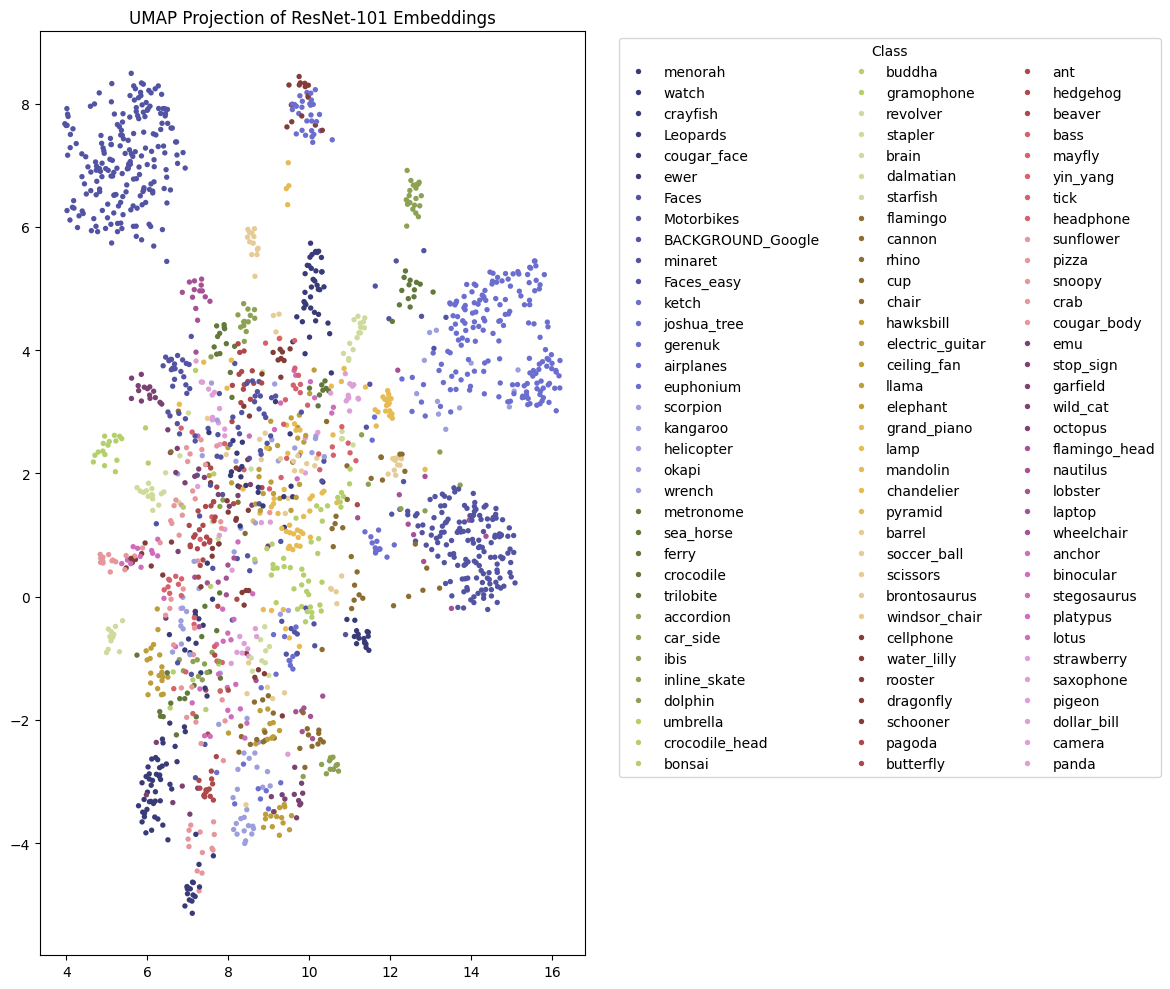

In [12]:
class_names = full_dataset.classes  # list of class names indexed by label id

# Convert numeric labels → class names
label_names = [class_names[i] for i in labels]

# Plot with class names instead of indices
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=embedding_2d[:, 0], 
    y=embedding_2d[:, 1], 
    hue=label_names, 
    palette=palette, 
    s=15, 
    linewidth=0
)

plt.title("UMAP Projection of ResNet-101 Embeddings")
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=3)
plt.tight_layout()
plt.show()

In [13]:
tsne = TSNE(n_components=2, perplexity=30, metric='cosine', n_iter=1000)
tsne_2d = tsne.fit_transform(embeddings)

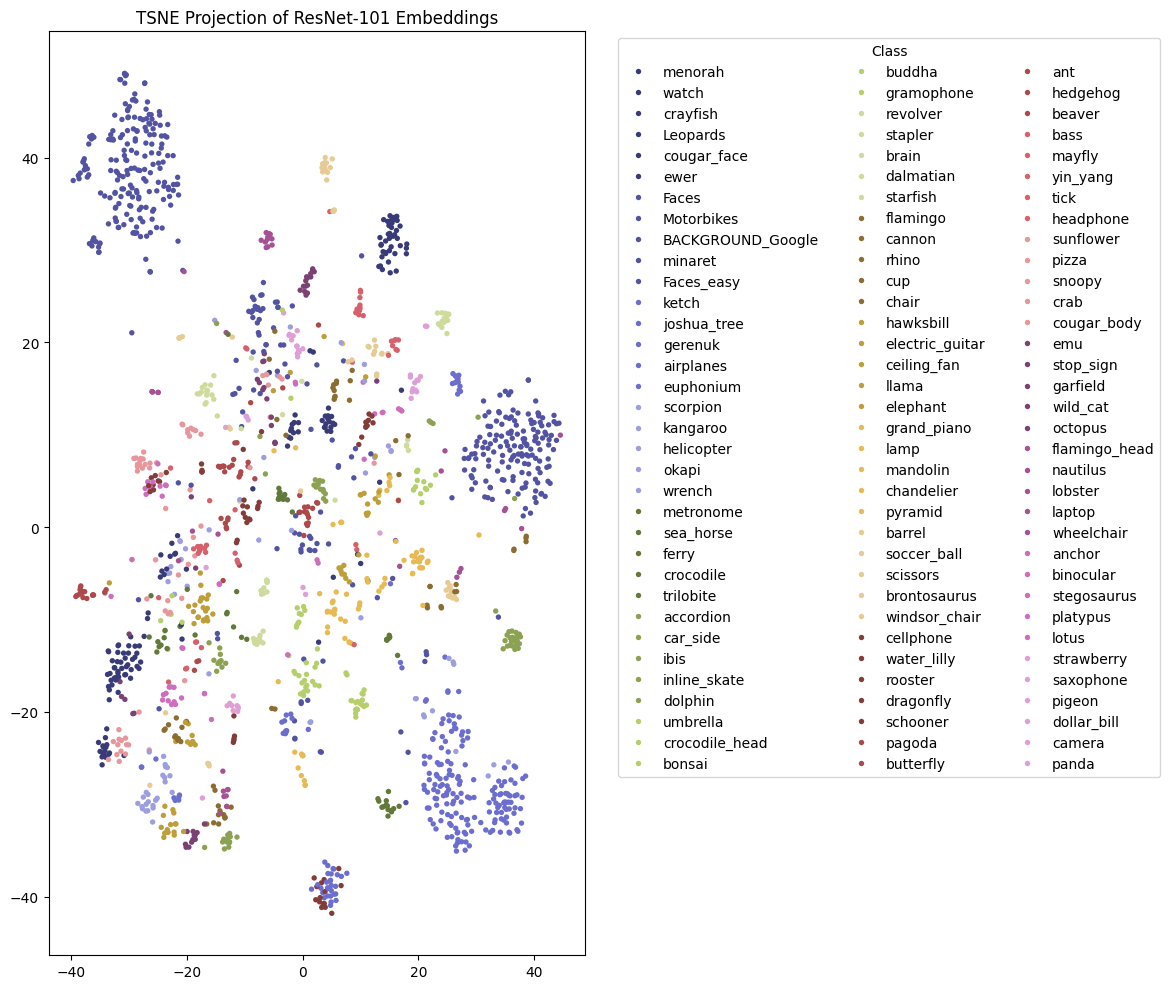

In [14]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=tsne_2d[:, 0], 
    y=tsne_2d[:, 1], 
    hue=label_names, 
    palette=palette, 
    s=15, 
    linewidth=0
)

plt.title("TSNE Projection of ResNet-101 Embeddings")
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=3)
plt.tight_layout()
plt.show()

In [15]:
# Map each class label to list of indices
label_to_indices = defaultdict(list)
for idx, label in enumerate(labels):
    label_to_indices[label].append(idx)

# Randomly pick one index per class (for top 10 classes)
class_to_idx = {}
top_k = 10
selected_labels = list(label_to_indices.keys())[:top_k]  # You can shuffle this if needed

for label in selected_labels:
    class_to_idx[label] = random.choice(label_to_indices[label])


top_k = 10
results = {}

for class_label, query_idx in class_to_idx.items():
    query_embedding = embeddings[query_idx].reshape(1, -1)

    # Compute cosine similarity to all embeddings
    similarities = cosine_similarity(query_embedding, embeddings)[0]  # shape: [10000]

    # Get top K most similar indices (excluding the query itself)
    similar_indices = similarities.argsort()[::-1][1:top_k+1]

    results[class_label] = {
        "query_idx": query_idx,
        "neighbors": similar_indices
    }
    
    
def unnormalize(img_tensor):
    """
    Undo normalization to convert image tensor to [0,1] range for imshow
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_tensor = img_tensor.cpu() * std + mean
    img_tensor = torch.clamp(img_tensor, 0, 1)
    return img_tensor


def show_neighbors(dataset, query_idx, neighbor_indices, class_name):
    plt.figure(figsize=(12, 2))

    # Query image
    plt.subplot(1, top_k + 1, 1)
    query_img = unnormalize(dataset[query_idx][0])
    plt.imshow(query_img.permute(1, 2, 0).numpy())
    plt.title(f"Query\nClass: {class_name}")
    plt.axis('off')

    # Neighbors
    for i, idx in enumerate(neighbor_indices):
        plt.subplot(1, top_k + 1, i + 2)
        nn_img = unnormalize(dataset[idx][0])
        plt.imshow(nn_img.permute(1, 2, 0).numpy())

        # Get the actual label name from dataset.labels or dataset.targets
        nn_label_idx = dataset[idx][1]  # This is the label index
        nn_label_name = dataset.dataset.classes[nn_label_idx]


        plt.title(f"NN {i+1}\n{nn_label_name}", fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

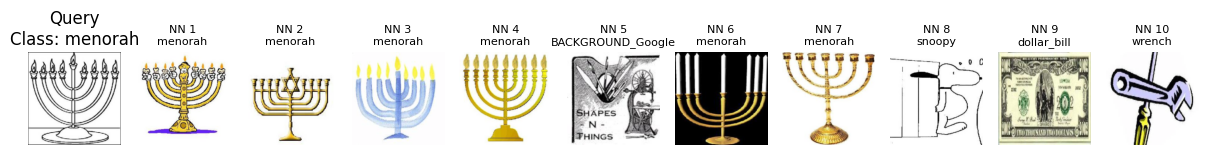

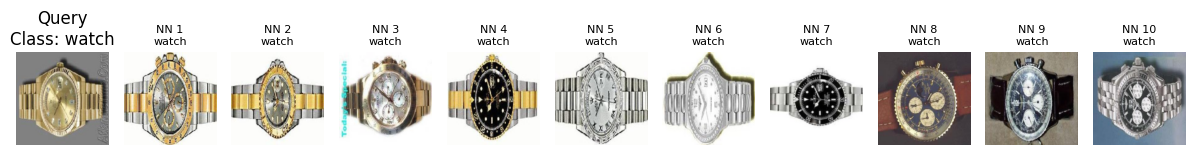

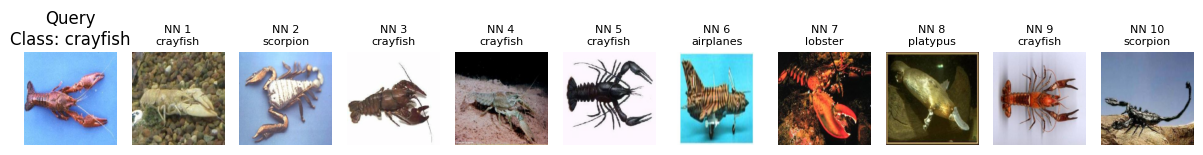

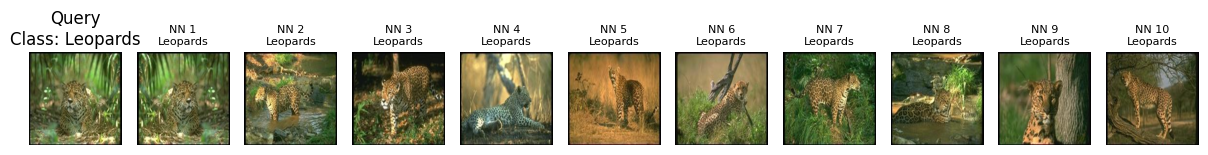

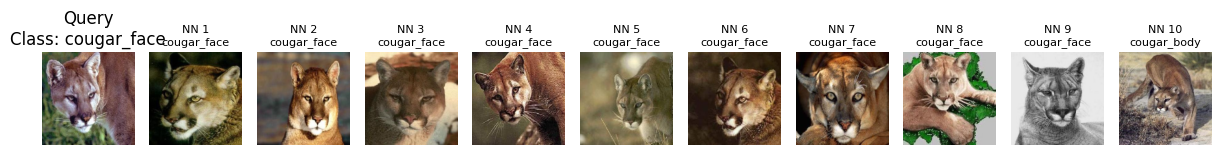

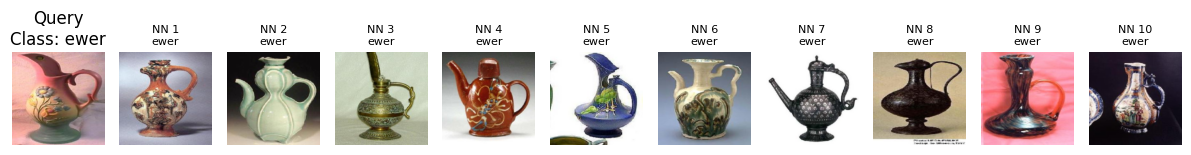

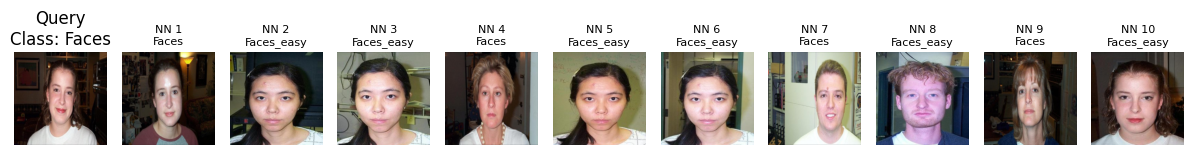

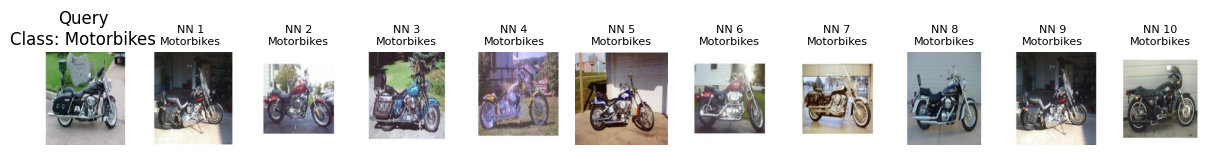

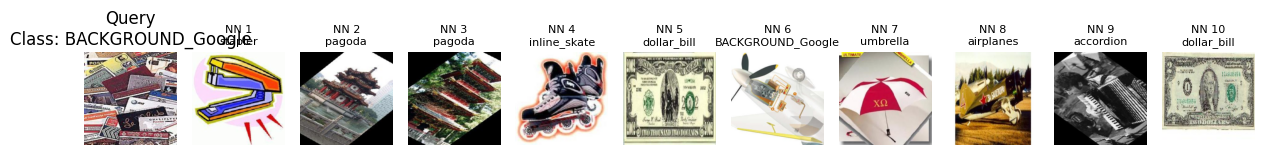

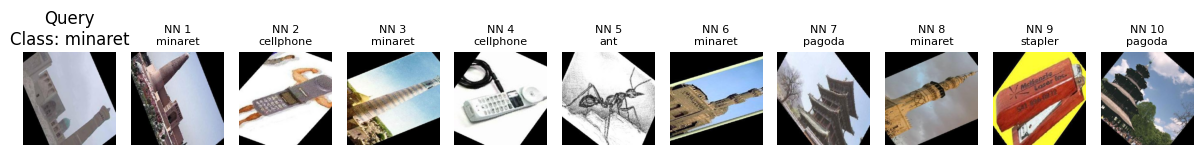

In [16]:
for class_label, data in results.items():
    show_neighbors(
        dataset=test_dataset,
        query_idx=data["query_idx"],
        neighbor_indices=data["neighbors"],
        class_name=test_dataset.dataset.classes[class_label]   # ← note the extra `.dataset`
    )

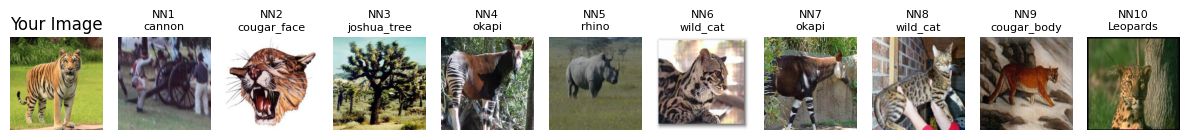

In [17]:
from PIL import Image

# Parameters
your_image_path = r"C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\Random_Images\tiger.jpg"  # Replace with your image path
device 
top_k = 10

# 1. Load and preprocess your image
img = Image.open(your_image_path).convert("RGB")
img_t = transform(img).unsqueeze(0).to(device)  # reuse `transform` and `device` from above

# 2. Extract its embedding
model.eval()
with torch.no_grad():
    feat = model(img_t)         # [1, 512, 1, 1]
    feat = feat.squeeze().cpu().numpy().reshape(1, -1)

# 3. Compute cosine similarities to all saved embeddings
all_emb = embeddings          # loaded earlier: np.load("embeddings/...npy")
sims = cosine_similarity(feat, all_emb)[0]

# 4. Get top_k neighbor indices (skip the image itself if accidentally included)
neighbor_idxs = sims.argsort()[::-1][:top_k]

# 5. Display query + neighbors
plt.figure(figsize=(12, 2))

# Query
plt.subplot(1, top_k+1, 1)
plt.imshow(img.resize((224,224)))
plt.title("Your Image")
plt.axis("off")

# Neighbors
for i, idx in enumerate(neighbor_idxs):
    ds_img, ds_lbl = test_dataset[idx]
    nn_img = unnormalize(ds_img)  # reuse unnormalize function
    plt.subplot(1, top_k+1, i+2)
    plt.imshow(nn_img.permute(1,2,0).numpy())
    plt.title(f"NN{i+1}\n{test_dataset.dataset.classes[ds_lbl]}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# Prepare for transfer learning - freeze feature extractor and train only classifier
model = torchvision.models.googlenet(pretrained=True,aux_logits=True)

# Freeze all feature extractor layers
for param in model.parameters():
    param.requires_grad = False


model.fc = nn.Linear(1024, 102)

# Also replace auxiliary classifiers if they exist
if hasattr(model, 'aux1'):
    model.aux1.fc2 = nn.Linear(1024, 102)
if hasattr(model, 'aux2'):
    model.aux2.fc2 = nn.Linear(1024, 102)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Define loss function and optimizer (only for classifier parameters)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([
    {'params': model.fc.parameters()},
    {'params': model.aux1.fc2.parameters()} if hasattr(model, 'aux1') else None,
    {'params': model.aux2.fc2.parameters()} if hasattr(model, 'aux2') else None
], lr=0.001)
# Filter out None parameters
optimizer.param_groups = [group for group in optimizer.param_groups if group['params']]

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\googlenet.py:338: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


In [5]:
print(model)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [6]:
data_dir = r"C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\data\caltech-101"

train_dataset = ImageFolder(
    root=data_dir,
    transform=transform   # same transform you defined earlier (resize + normalize)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [7]:
# Training loop
num_epochs = 10
train_losses = []
val_losses = []
val_accuracies = []

In [8]:
print("Training classifier head...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs, aux1, aux2 = model(images)
        loss = criterion(outputs, labels) + 0.3 * criterion(aux1, labels) + 0.3 * criterion(aux2, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    scheduler.step()
    
    # Calculate validation loss and accuracy
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_train_loss = running_loss / len(train_loader)
    epoch_val_loss = val_loss / len(test_loader)
    epoch_val_acc = 100. * correct / total
    
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}: Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

Training classifier head...


Epoch 1/10: 100%|██████████| 143/143 [00:30<00:00,  4.66it/s]


Epoch 1: Train Loss: 3.9730, Val Loss: 0.7914, Val Acc: 87.97%


Epoch 2/10: 100%|██████████| 143/143 [00:26<00:00,  5.38it/s]


Epoch 2: Train Loss: 1.8128, Val Loss: 0.4079, Val Acc: 93.17%


Epoch 3/10: 100%|██████████| 143/143 [00:25<00:00,  5.61it/s]


Epoch 3: Train Loss: 1.3367, Val Loss: 0.2938, Val Acc: 94.81%


Epoch 4/10: 100%|██████████| 143/143 [00:26<00:00,  5.37it/s]


Epoch 4: Train Loss: 1.0961, Val Loss: 0.2218, Val Acc: 95.95%


Epoch 5/10: 100%|██████████| 143/143 [00:26<00:00,  5.38it/s]


Epoch 5: Train Loss: 0.9530, Val Loss: 0.1789, Val Acc: 96.72%


Epoch 6/10: 100%|██████████| 143/143 [00:25<00:00,  5.55it/s]


Epoch 6: Train Loss: 0.8516, Val Loss: 0.1585, Val Acc: 97.43%


Epoch 7/10: 100%|██████████| 143/143 [00:25<00:00,  5.61it/s]


Epoch 7: Train Loss: 0.8039, Val Loss: 0.1416, Val Acc: 97.76%


Epoch 8/10: 100%|██████████| 143/143 [00:26<00:00,  5.32it/s]


Epoch 8: Train Loss: 0.7575, Val Loss: 0.1313, Val Acc: 97.70%


Epoch 9/10: 100%|██████████| 143/143 [00:25<00:00,  5.50it/s]


Epoch 9: Train Loss: 0.7299, Val Loss: 0.1221, Val Acc: 97.92%


Epoch 10/10: 100%|██████████| 143/143 [00:25<00:00,  5.70it/s]


Epoch 10: Train Loss: 0.7009, Val Loss: 0.1118, Val Acc: 98.36%


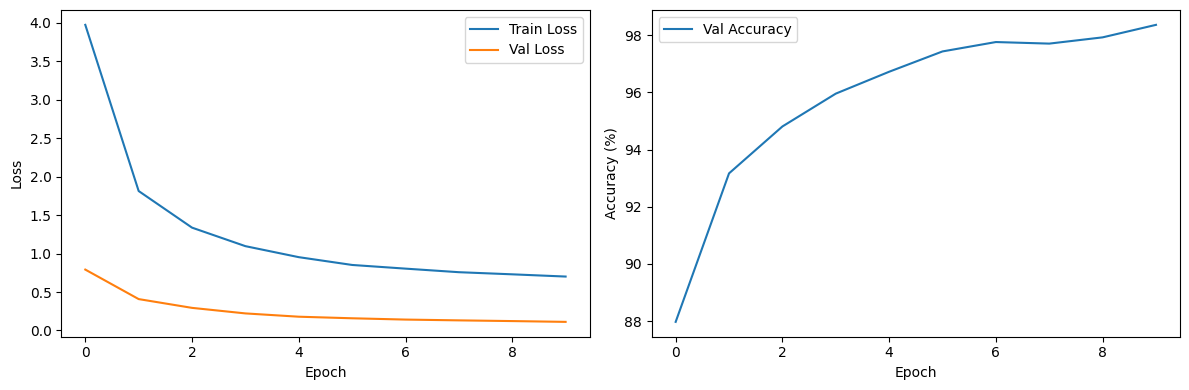

In [9]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Comprehensive evaluation on test set
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm.tqdm(test_loader, desc="Evaluating"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate metrics
accuracy = 100.0 * np.mean(all_preds == all_labels)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')

print(f"\nFinal Test Accuracy: {accuracy:.2f}%")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=test_dataset.dataset.classes))

Evaluating: 100%|██████████| 29/29 [00:16<00:00,  1.81it/s]


Final Test Accuracy: 98.36%
Weighted Precision: 0.9850
Weighted Recall: 0.9836
Weighted F1-Score: 0.9835

Classification Report:
                   precision    recall  f1-score   support

BACKGROUND_Google       0.89      0.96      0.92        89
            Faces       0.99      0.98      0.98        96
       Faces_easy       0.99      0.99      0.99        96
         Leopards       1.00      1.00      1.00        34
       Motorbikes       1.00      1.00      1.00       157
        accordion       1.00      1.00      1.00        18
        airplanes       1.00      1.00      1.00       153
           anchor       1.00      1.00      1.00         8
              ant       1.00      0.90      0.95        10
           barrel       1.00      1.00      1.00         8
             bass       1.00      1.00      1.00        17
           beaver       1.00      1.00      1.00         8
        binocular       1.00      1.00      1.00         5
           bonsai       1.00      1.00     

In [14]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(100, 80))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=test_dataset.dataset.classes, 
            yticklabels=test_dataset.dataset.classes)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

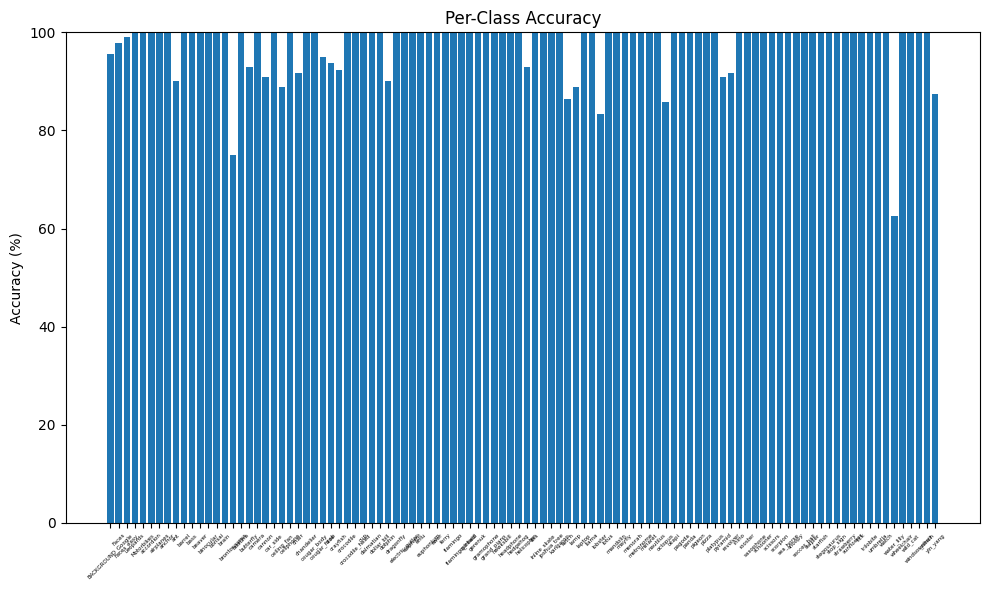

In [24]:
# Per-class accuracy
class_correct = np.zeros(102)
class_total = np.zeros(102)
for i in range(102):
    idx = all_labels == i
    class_correct[i] = np.sum(all_preds[idx] == i)
    class_total[i] = np.sum(idx)

class_accuracies = 100 * class_correct / class_total

plt.figure(figsize=(10, 6))
plt.bar(range(102), class_accuracies)
plt.xticks(range(102), test_dataset.dataset.classes, rotation=45, fontsize=4)
plt.title('Per-Class Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

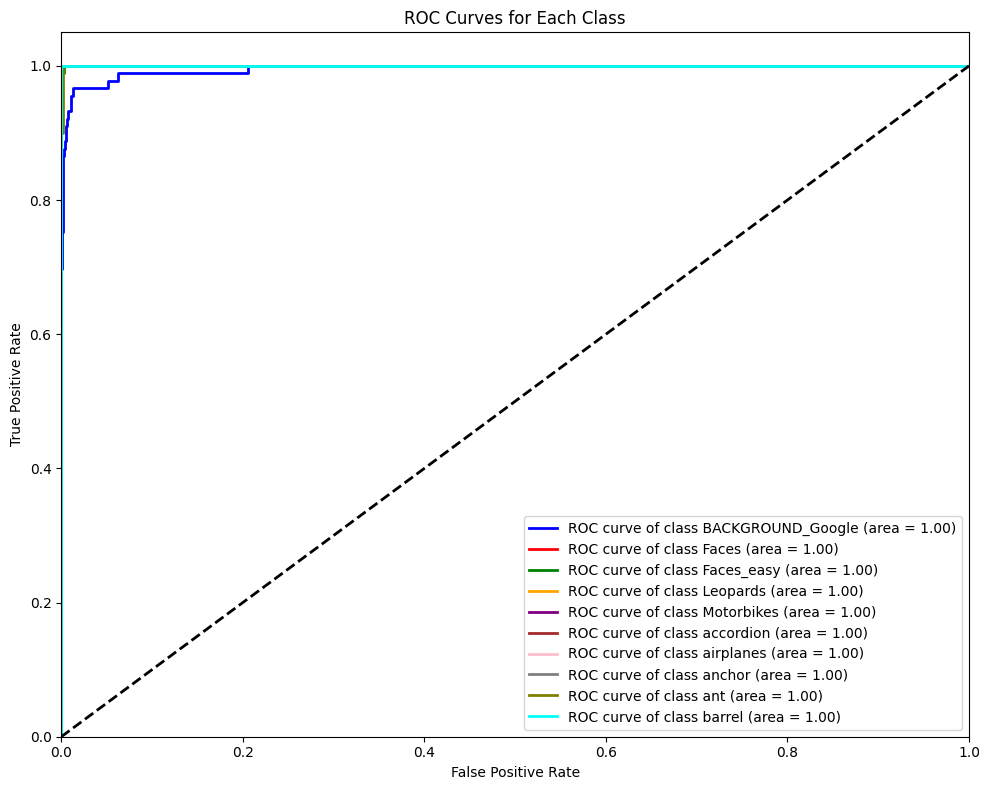


=== TRANSFER LEARNING EVALUATION SUMMARY ===
Test Accuracy: 98.36%
Weighted Precision: 0.9850
Weighted Recall: 0.9836
Weighted F1-Score: 0.9835
Mean ROC AUC: 0.9999


In [27]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output for multi-class ROC
y_test_bin = label_binarize(all_labels, classes=range(102))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(102):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
for i, color in zip(range(102), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(test_dataset.dataset.classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Class')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Print final summary
print("\n=== TRANSFER LEARNING EVALUATION SUMMARY ===")
print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")
print(f"Mean ROC AUC: {np.mean(list(roc_auc.values())):.4f}")